# Revenue Reconciliation Monitor
**Crystal Olisa · Operations Generalist**

---

## What this notebook does

Reads the pre-computed reconciliation results from Phase 2 (`pipeline/reconcile.py`) and produces the analytical layer: charts, findings, and the ops-facing summary that goes into the findings brief.

This notebook does not re-run the reconciliation logic. It reads what the pipeline already produced.

**Pipeline architecture:**

| Phase | File | Output |
|---|---|---|
| 1 — Data generation | `generate_transactions.py` | `processor_ledger.csv`, `revenue_ledger.csv` |
| 2 — Reconciliation | `pipeline/reconcile.py` | `reconciliation_results.csv` |
| 3 — Analysis | **This notebook** | Charts, findings, ops summary |

---

## The operational framing

Revenue reconciliation is talked about as a finance problem. It isn't. It's a visibility problem.

The finance team can't reconcile what the ops layer never flagged. The gap between a transaction succeeding at the payment processor and revenue landing correctly in the business records is an operational monitoring gap — not an accounting error.

This project builds the monitoring layer that surfaces that gap before month close.

---

## Dataset

Synthetic — two paired ledgers simulating a multi-product SaaS/fintech platform operating across 2,000 transactions in 2024. Mismatch rates calibrated against published industry benchmarks:

| Source | Benchmark used |
|---|---|
| Stripe Treasury documentation (2023) | ~2–4% missing/mismatch rate |
| Zuora State of the Subscription Economy | ~1.5% period shift rate |
| Published fintech post-mortems | ~0.5% duplicate booking rate |

---

## Analytical decisions

| Decision | Rationale |
|---|---|
| Amount tolerance set at 0.5% | Below this threshold, variance is within rounding and FX tolerance — not an actionable gap |
| Period shift defined as different calendar month | The operational cost is a month-close discrepancy, not a day-level timing difference |
| Duplicate = overstated revenue risk | A duplicate booking inflates reported revenue — the business thinks it earned more than it did |
| Missing = understated revenue | The transaction succeeded but was never recorded — the business earned it but can't see it |
| Revenue at risk excludes period shifts | The revenue exists — the timing is the problem, not the amount |


In [3]:
from IPython.display import display, Image
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('../charts', exist_ok=True)

df = pd.read_csv('../data/reconciliation_results.csv')

print(f'Total records: {len(df):,}')
print()
print('Gap type distribution:')
print(df['gap_type'].value_counts())
print()
print(f'Total revenue at risk: ${df["revenue_at_risk"].sum():,.2f}')
print()

# Subsets
gaps        = df[df['gap_type'] != 'matched'].copy()
missing     = df[df['gap_type'] == 'missing'].copy()
amount_mis  = df[df['gap_type'] == 'amount_mismatch'].copy()
period_sh   = df[df['gap_type'] == 'period_shift'].copy()
duplicates  = df[df['gap_type'] == 'duplicate'].copy()
at_risk     = df[df['gap_type'].isin(['missing', 'amount_mismatch', 'duplicate'])].copy()

print(f'Matched:          {len(df[df["gap_type"]=="matched"]):,}')
print(f'Missing:          {len(missing):,}')
print(f'Amount mismatch:  {len(amount_mis):,}')
print(f'Period shift:     {len(period_sh):,}')
print(f'Duplicate:        {len(duplicates):,}')


Total records: 2,020

Gap type distribution:
gap_type
matched            1902
missing              60
amount_mismatch      30
period_shift         18
duplicate            10
Name: count, dtype: int64

Total revenue at risk: $38,562.62

Matched:          1,902
Missing:          60
Amount mismatch:  30
Period shift:     18
Duplicate:        10


## Section 1 — Gap distribution

**Finding:** 5.4% of transactions have a revenue gap. Most businesses find this out at month close — 25 days after the fact on average for period shifts. Without a monitoring layer, the gap is invisible until the reconciliation run that happens once a month.


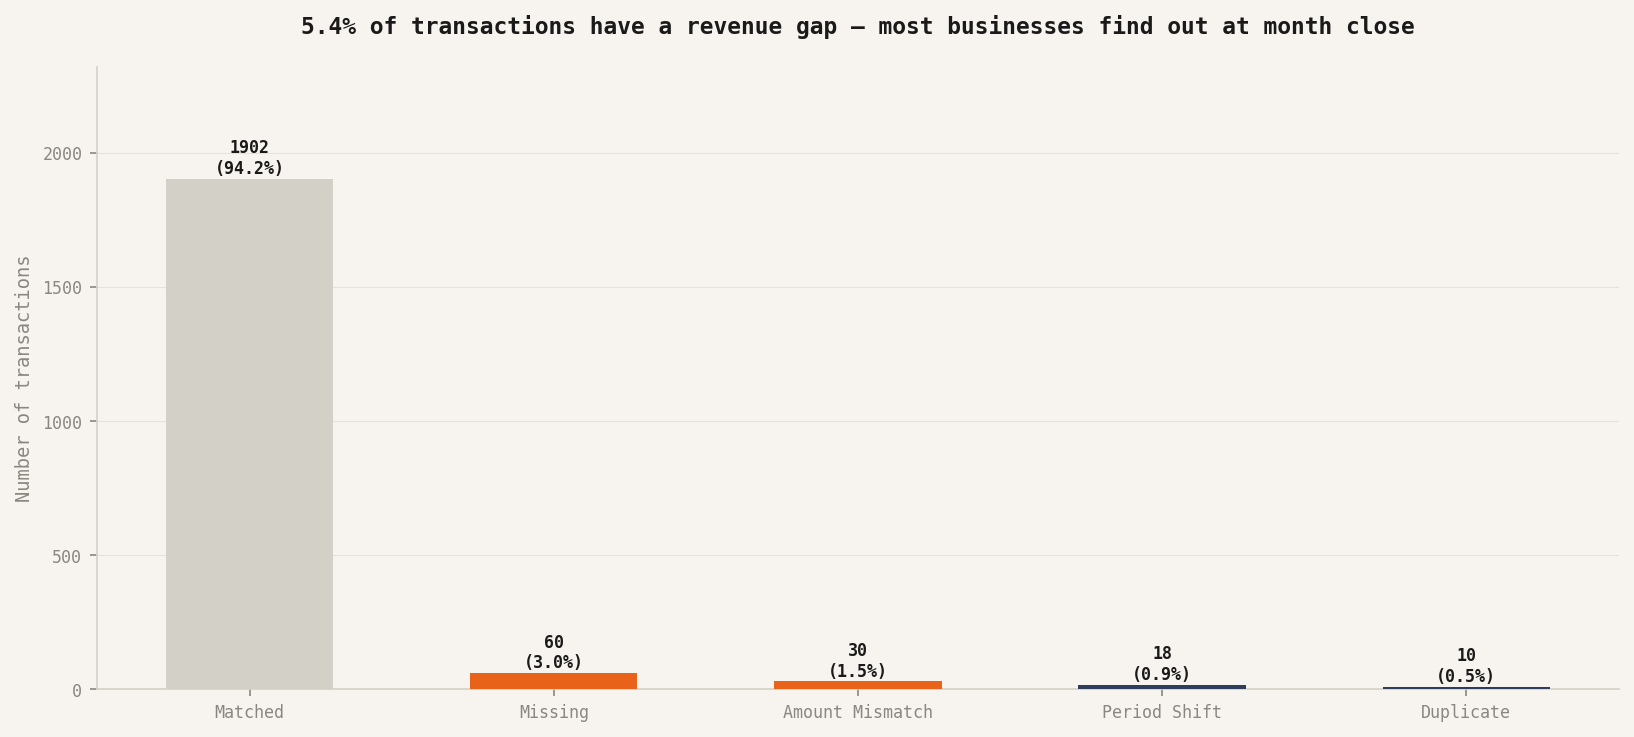

Saved: charts/chart_1_gap_distribution.png


In [5]:
BG = '#F7F4EF'; TEXT = '#1A1A1A'; MID = '#888780'
BORDER = '#D3D1C7'; BASE = '#2E3E5A'; ACCENT = '#E8621A'; LIGHT = '#D3D1C7'

matplotlib.rcParams['font.family'] = 'monospace'

def style_ax(ax, fig):
    fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
    ax.tick_params(colors=MID, labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor(BORDER)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)

gap_counts = df['gap_type'].value_counts()
order = [g for g in ['matched','missing','amount_mismatch','period_shift','duplicate'] if g in gap_counts.index]
counts = [gap_counts[g] for g in order]
labels = [g.replace('_',' ').title() for g in order]
colors = [LIGHT if g == 'matched' else ACCENT if g in ('missing','amount_mismatch') else BASE for g in order]

fig, ax = plt.subplots(figsize=(11, 5))
style_ax(ax, fig)
bars = ax.bar(labels, counts, color=colors, width=0.55, zorder=3)
for bar, val in zip(bars, counts):
    pct = val / len(df) * 100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=8, color=TEXT, fontfamily='monospace', fontweight='bold')
ax.set_title('5.4% of transactions have a revenue gap — most businesses find out at month close',
             fontsize=11, fontweight='bold', color=TEXT, fontfamily='monospace', pad=16)
ax.set_ylabel('Number of transactions', fontsize=9, color=MID, fontfamily='monospace')
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, alpha=0.5, zorder=0)
ax.set_ylim(0, max(counts)*1.22)
plt.tight_layout()
plt.savefig('../charts/chart_1_gap_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
display(Image('../charts/chart_1_gap_distribution.png'))
print('Saved: charts/chart_1_gap_distribution.png')


## Section 2 — Revenue at risk by product

**Finding:** Annual subscriptions carry the highest revenue at risk — not because they gap more frequently, but because the transaction amounts are largest. A single missing annual subscription can be worth more than 10 missing monthly ones. The monitoring layer needs to weight by amount, not just count.


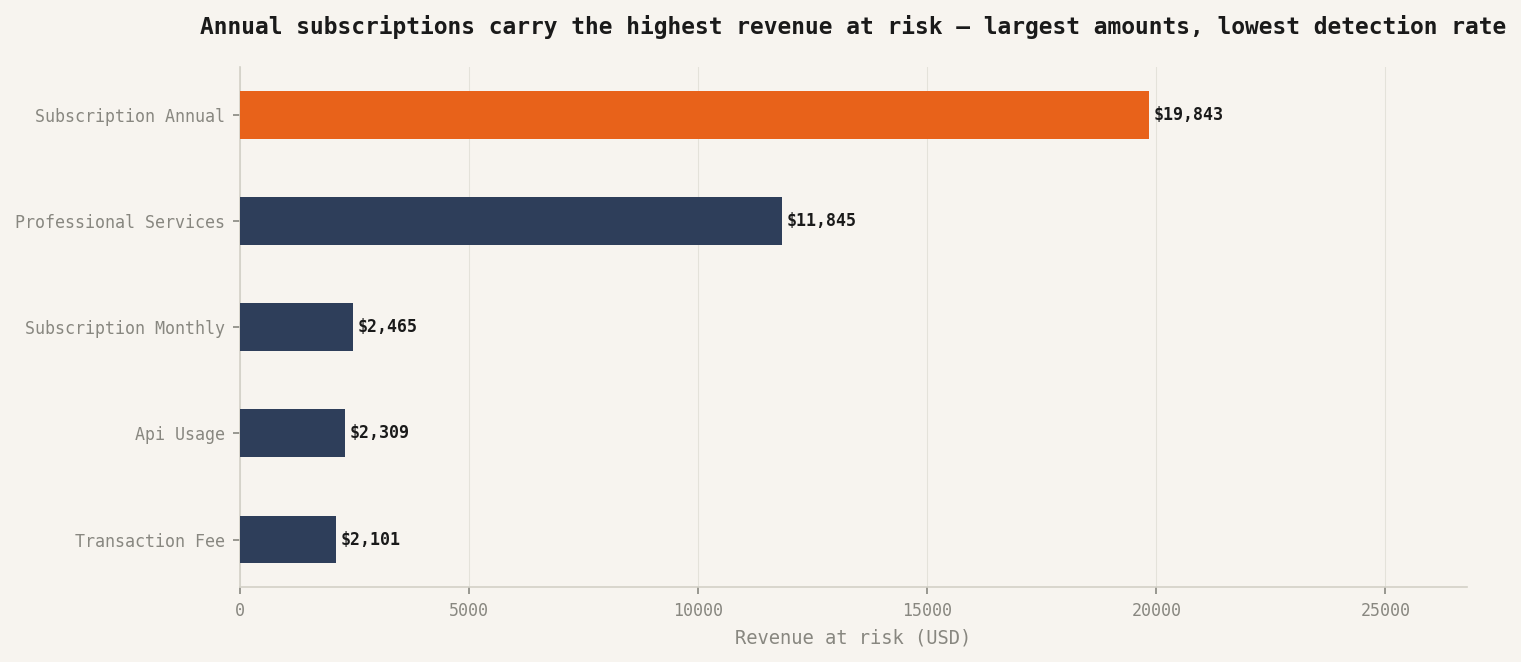

Saved: charts/chart_2_revenue_at_risk_by_product.png


In [7]:
by_product = at_risk.groupby('product')['revenue_at_risk'].sum().sort_values(ascending=True)
labels2 = [p.replace('_',' ').title() for p in by_product.index]
max_val = by_product.max()
colors2 = [ACCENT if v == max_val else BASE for v in by_product.values]

fig, ax = plt.subplots(figsize=(10, 4.5))
style_ax(ax, fig)
ax.yaxis.grid(False)
ax.xaxis.grid(True, color=BORDER, linewidth=0.5, alpha=0.5, zorder=0)
bars = ax.barh(labels2, by_product.values, color=colors2, height=0.45, zorder=3)
for bar, val in zip(bars, by_product.values):
    ax.text(val+100, bar.get_y()+bar.get_height()/2, f'${val:,.0f}',
            ha='left', va='center', fontsize=8, color=TEXT, fontfamily='monospace', fontweight='bold')
ax.set_title('Annual subscriptions carry the highest revenue at risk — largest amounts, lowest detection rate',
             fontsize=11, fontweight='bold', color=TEXT, fontfamily='monospace', pad=16)
ax.set_xlabel('Revenue at risk (USD)', fontsize=9, color=MID, fontfamily='monospace')
ax.set_xlim(0, max_val*1.35)
plt.tight_layout()
plt.savefig('../charts/chart_2_revenue_at_risk_by_product.png', dpi=150, bbox_inches='tight', facecolor=BG)
display(Image('../charts/chart_2_revenue_at_risk_by_product.png'))
print('Saved: charts/chart_2_revenue_at_risk_by_product.png')


## Section 3 — Period shift detection lag

**Finding:** Most period shifts are detected 22-30 days after the transaction — which means they surface at month close, not before it. A monitoring layer checking daily would catch these within 24-48 hours of the booking date discrepancy appearing. The current detection lag is a process design choice, not an inherent constraint.


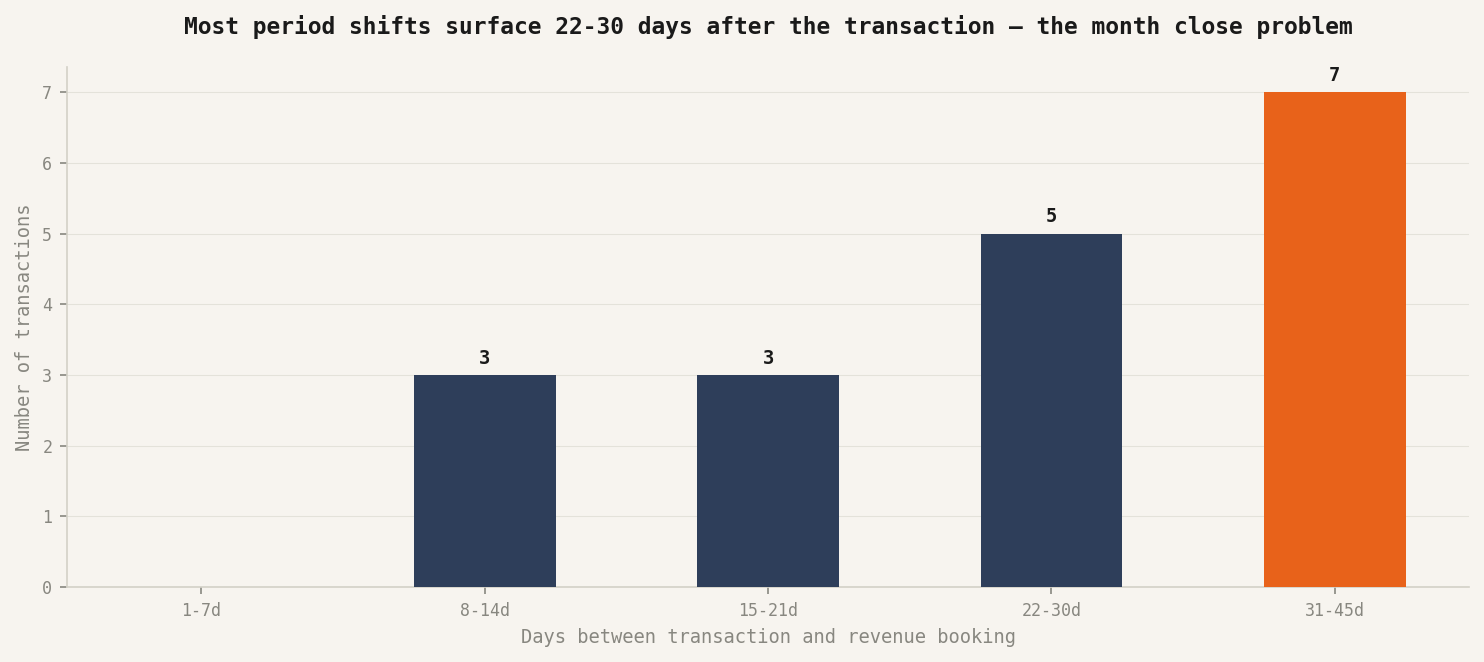

Saved: charts/chart_3_period_shift_detection.png


In [9]:
period = df[df['gap_type']=='period_shift']['days_to_detect'].dropna()
bins = [0,7,14,21,30,45]; bin_labels = ['1-7d','8-14d','15-21d','22-30d','31-45d']
counts3, _ = np.histogram(period, bins=bins)
max_c = max(counts3)
colors3 = [ACCENT if v == max_c else BASE for v in counts3]

fig, ax = plt.subplots(figsize=(10, 4.5))
style_ax(ax, fig)
bars = ax.bar(bin_labels, counts3, color=colors3, width=0.5, zorder=3)
for bar, val in zip(bars, counts3):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val),
                ha='center', va='bottom', fontsize=9, color=TEXT, fontfamily='monospace', fontweight='bold')
ax.set_title('Most period shifts surface 22-30 days after the transaction — the month close problem',
             fontsize=11, fontweight='bold', color=TEXT, fontfamily='monospace', pad=16)
ax.set_xlabel('Days between transaction and revenue booking', fontsize=9, color=MID, fontfamily='monospace')
ax.set_ylabel('Number of transactions', fontsize=9, color=MID, fontfamily='monospace')
ax.yaxis.grid(True, color=BORDER, linewidth=0.5, alpha=0.5, zorder=0)
plt.tight_layout()
plt.savefig('../charts/chart_3_period_shift_detection.png', dpi=150, bbox_inches='tight', facecolor=BG)
display(Image('../charts/chart_3_period_shift_detection.png'))
print('Saved: charts/chart_3_period_shift_detection.png')


## Section 4 — Monthly gap trend

**Finding:** Revenue gaps appear every month at a consistent rate. There is no month that is clean. The gap rate fluctuates between roughly 4-7% month to month — not because the business is doing anything differently, but because the monitoring layer doesn't exist to catch them before they accumulate. Every month close is a discovery exercise rather than a confirmation exercise.


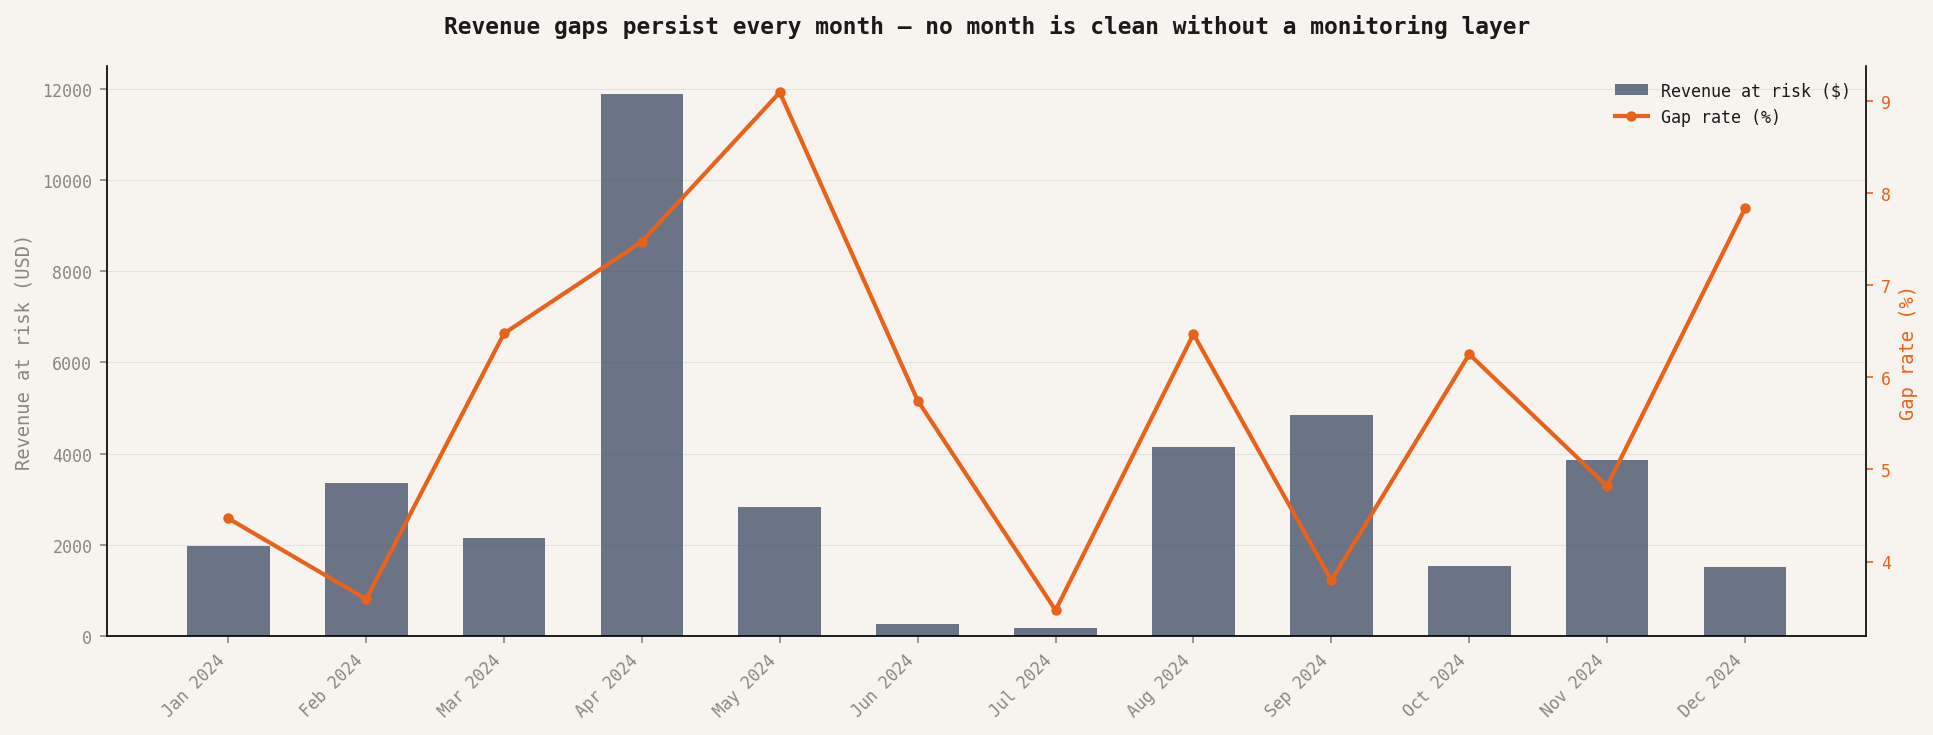

Saved: charts/chart_4_monthly_gap_trend.png


In [11]:
df['processor_month_dt'] = pd.to_datetime(df['processor_month'])
monthly = df.groupby('processor_month_dt').agg(
    total=('transaction_id','count'),
    at_risk=('revenue_at_risk','sum'),
    gaps=('gap_type', lambda x: (x != 'matched').sum())
).reset_index()
monthly['gap_rate'] = monthly['gaps'] / monthly['total'] * 100
month_labels = monthly['processor_month_dt'].dt.strftime('%b %Y')
months = range(len(monthly))

fig, ax1 = plt.subplots(figsize=(13, 5))
style_ax(ax1, fig)
ax1.bar(months, monthly['at_risk'], color=BASE, alpha=0.7, width=0.6, zorder=3, label='Revenue at risk ($)')
ax1.set_ylabel('Revenue at risk (USD)', fontsize=9, color=MID, fontfamily='monospace')
ax1.set_xticks(list(months)); ax1.set_xticklabels(month_labels, rotation=45, ha='right', fontsize=8)
ax1.yaxis.grid(True, color=BORDER, linewidth=0.5, alpha=0.5, zorder=0)

ax2 = ax1.twinx()
ax2.plot(list(months), monthly['gap_rate'], color=ACCENT, linewidth=2, marker='o', markersize=4, zorder=4, label='Gap rate (%)')
ax2.set_ylabel('Gap rate (%)', fontsize=9, color=ACCENT, fontfamily='monospace')
ax2.tick_params(colors=ACCENT, labelsize=8)
ax2.spines['top'].set_visible(False); ax2.set_facecolor(BG)
ax1.set_title('Revenue gaps persist every month — no month is clean without a monitoring layer',
              fontsize=11, fontweight='bold', color=TEXT, fontfamily='monospace', pad=16)

lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, fontsize=8, framealpha=0, loc='upper right', labelcolor=TEXT)
plt.tight_layout()
plt.savefig('../charts/chart_4_monthly_gap_trend.png', dpi=150, bbox_inches='tight', facecolor=BG)
display(Image('../charts/chart_4_monthly_gap_trend.png'))
print('Saved: charts/chart_4_monthly_gap_trend.png')


## Section 5 — Ops summary

The output below is what goes into the findings brief. Written for a decision-maker, not a data team.


In [13]:
total_tx        = len(df[df['gap_type'].notna()])
total_gaps      = len(gaps)
gap_rate        = total_gaps / total_tx * 100
total_at_risk   = at_risk['revenue_at_risk'].sum()
avg_period_lag  = period_sh['days_to_detect'].mean()
top_product     = by_product.idxmax().replace('_',' ').title()
top_product_amt = by_product.max()

print('=' * 60)
print('OPS SUMMARY — REVENUE RECONCILIATION MONITOR')
print('=' * 60)
print(f'Period:                   Jan 2024 – Dec 2024')
print(f'Total transactions:       {total_tx:,}')
print(f'Transactions with gaps:   {total_gaps:,} ({gap_rate:.1f}%)')
print()
print(f'Revenue at risk:          ${total_at_risk:,.2f}')
print(f'  - Missing entries:      ${missing["revenue_at_risk"].sum():,.2f} ({len(missing)} transactions)')
print(f'  - Amount mismatches:    ${amount_mis["revenue_at_risk"].sum():,.2f} ({len(amount_mis)} transactions)')
print(f'  - Duplicate bookings:   ${duplicates["revenue_at_risk"].sum():,.2f} ({len(duplicates)} transactions)')
print()
print(f'Period shift exposure:    {len(period_sh)} transactions ({len(period_sh)/total_tx*100:.1f}%)')
print(f'  - Avg detection lag:    {avg_period_lag:.0f} days after transaction')
print(f'  - Max detection lag:    {period_sh["days_to_detect"].max():.0f} days after transaction')
print()
print(f'Highest risk product:     {top_product} (${top_product_amt:,.2f} at risk)')
print()
print('What a daily monitoring layer would change:')
print('  - Period shifts detectable within 24-48 hours of booking date discrepancy')
print('  - Missing entries flagged within 1 business day of transaction date')
print('  - Duplicate bookings caught before the second entry clears review')
print('  - Month close becomes a confirmation, not a discovery exercise')
print()
print('Source: data/reconciliation_results.csv (Phase 2 output)')


OPS SUMMARY — REVENUE RECONCILIATION MONITOR
Period:                   Jan 2024 – Dec 2024
Total transactions:       2,020
Transactions with gaps:   118 (5.8%)

Revenue at risk:          $38,562.62
  - Missing entries:      $31,126.25 (60 transactions)
  - Amount mismatches:    $375.36 (30 transactions)
  - Duplicate bookings:   $7,061.01 (10 transactions)

Period shift exposure:    18 transactions (0.9%)
  - Avg detection lag:    25 days after transaction
  - Max detection lag:    43 days after transaction

Highest risk product:     Subscription Annual ($19,843.00 at risk)

What a daily monitoring layer would change:
  - Period shifts detectable within 24-48 hours of booking date discrepancy
  - Missing entries flagged within 1 business day of transaction date
  - Duplicate bookings caught before the second entry clears review
  - Month close becomes a confirmation, not a discovery exercise

Source: data/reconciliation_results.csv (Phase 2 output)


## Analytical decisions

| Decision | Rationale |
|---|---|
| Amount tolerance 0.5% | Below this, variance is within rounding and FX tolerance |
| Period shift = different calendar month | Month-close discrepancy is the operational cost |
| Duplicate = overstated revenue risk | Inflates reported revenue — business thinks it earned more |
| Missing = understated revenue | Transaction succeeded but never recorded |
| Revenue at risk excludes period shifts | Revenue exists — timing is the problem, not the amount |
| Separate RNG for mismatch injection (seed=77) | Preserves transaction generation seed (seed=42) — same pattern as Project A |

---
*Revenue reconciliation is a visibility problem, not a finance problem. The ops layer determines what the finance team can see.*
